# Grammar Scoring Engine for Spoken Audio 


**Goal:** predict a continuous MOS grammar score (0-5) from a 45-60 s speech clip.


**Approach in one line:** Whisper ASR -> transcript -> grammar/fluency features (GPT-2 perplexity, LanguageTool errors, linguistic stats, sentence embeddings) + acoustic embeddings (wav2vec2) -> ensemble of Ridge / SVR / Gradient Boosting, validated with 5-fold CV (RMSE).

In [1]:

!pip install -q transformers sentence-transformers librosa lightgbm language_tool_python soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 1.6 MB/s eta 0:00:00


In [2]:
import os, re, glob, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, torch
from tqdm.auto import tqdm
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SR = 16000


DATA_DIR = "/kaggle/input/" + os.listdir("/kaggle/input")[0] if os.path.exists("/kaggle/input") else "./data"
print("Data dir:", DATA_DIR, "| device:", DEVICE)
print(os.listdir(DATA_DIR))

Data dir: /kaggle/input/competitions | device: cuda
['shl-hiring-assessment-2026']


## 1. Load data & quick EDA

(769, 2) (216, 2) (204, 2)


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1


file col: filename | label col: label


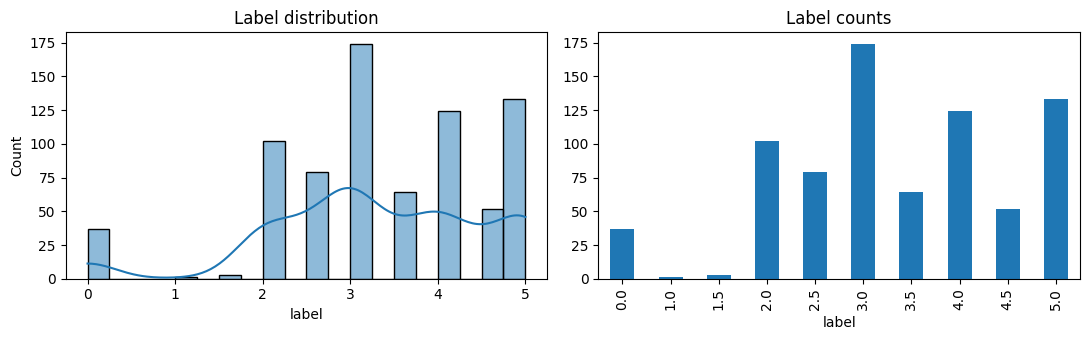

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


In [3]:
def find_csv(name):
    hits = glob.glob(f"{DATA_DIR}/**/{name}", recursive=True)
    assert hits, f"{name} not found under {DATA_DIR}"
    return hits[0]

train = pd.read_csv(find_csv("train.csv"))
test  = pd.read_csv(find_csv("test.csv"))
sub   = pd.read_csv(find_csv("sample_submission.csv"))
print(train.shape, test.shape, sub.shape); display(train.head(3)); display(sub.head(3))

FILE_COL  = train.columns[0]
LABEL_COL = [c for c in train.columns if c != FILE_COL][0]   # label column
print("file col:", FILE_COL, "| label col:", LABEL_COL)

# train.csv and test.csv reuse the same file names (audio_0, audio_1, ...) in separate
# train/ and test/ folders, so audio is matched per split folder to avoid train/test leakage.
def split_map(split):
    return {os.path.splitext(os.path.basename(p))[0]: p
            for p in glob.glob(f"{DATA_DIR}/**/{split}/**/*.wav", recursive=True)}

key = lambda f: os.path.splitext(str(f))[0]
tr_map, te_map = split_map("train"), split_map("test")
train["path"] = train[FILE_COL].map(lambda f: tr_map[key(f)])
test["path"]  = test[FILE_COL].map(lambda f: te_map[key(f)])
assert len(set(train.path) & set(test.path)) == 0, "train/test audio overlap!"

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(train[LABEL_COL], bins=20, kde=True, ax=ax[0]); ax[0].set_title("Label distribution")
train[LABEL_COL].value_counts().sort_index().plot.bar(ax=ax[1], title="Label counts")
plt.tight_layout(); plt.show()
print(train[LABEL_COL].describe())

## 2. Audio loading + speech-to-text (Whisper)
Audio is resampled to 16 kHz mono. Whisper-small transcribes each clip; transcripts are cached so the step runs once.
Note: Whisper tends to "clean up" some grammar errors, so we also use acoustic embeddings and fluency features as a complement.

In [4]:
def load_audio(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    return y

from transformers import pipeline
CACHE = "transcripts_by_path.csv"

def transcribe(paths):
    asr = pipeline("automatic-speech-recognition", model="openai/whisper-small",
                   device=0 if DEVICE == "cuda" else -1, chunk_length_s=30,
                   torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32)
    texts = []
    for p in tqdm(paths, desc="ASR"):
        out = asr({"raw": load_audio(p), "sampling_rate": SR},
                  generate_kwargs={"language": "en", "task": "transcribe"})
        texts.append(out["text"].strip())
    return texts

if os.path.exists(CACHE):
    tr = pd.read_csv(CACHE).set_index("path")["text"].fillna("").to_dict()
else:
    paths = pd.concat([train["path"], test["path"]]).tolist()
    tr = dict(zip(paths, transcribe(paths)))
    pd.DataFrame({"path": list(tr), "text": list(tr.values())}).to_csv(CACHE, index=False)

train["text"] = train["path"].map(tr).fillna("")
test["text"]  = test["path"].map(tr).fillna("")
display(train[[FILE_COL, LABEL_COL, "text"]].head())

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


ASR:   0%|          | 0/985 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,filename,label,text
0,audio_192.wav,3.0,"The playground is very, very beautiful and fun..."
1,audio_436.wav,3.0,The scene of a school playground. Our playgrou...
2,audio_447.wav,3.5,My favorite place to visit is the beach. I lov...
3,audio_126.wav,2.0,"Once upon a time, we with five friends went on..."
4,audio_61.wav,2.0,"Well, when I was a child, I remember I went to..."


## 3. Feature engineering
**(a) Linguistic / fluency stats** - length, sentence length, type-token ratio, fillers, repetitions, speech rate, pause ratio.
**(b) GPT-2 perplexity** - ungrammatical text is less probable under a language model.
**(c) LanguageTool error counts** - rule-based grammar errors per word (optional; falls back to zeros if Java is unavailable).
**(d) Sentence embeddings** (MiniLM) - semantic/syntactic style of the transcript.
**(e) wav2vec2 acoustic embeddings** - mean-pooled; captures hesitations, prosody, accent.

In [5]:
FILLERS = {"um","uh","umm","uhh","er","erm","ah","hmm","mm","like"}

def handcrafted(text, path):
    words = re.findall(r"[A-Za-z']+", text.lower())
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    n = max(len(words), 1)
    y = load_audio(path); dur = len(y) / SR
    voiced = sum(e - s for s, e in librosa.effects.split(y, top_db=30)) / SR
    rep = sum(1 for a, b in zip(words, words[1:]) if a == b)
    return dict(
        n_words=len(words), n_sents=len(sents), duration=dur,
        words_per_sent=len(words) / max(len(sents), 1),
        ttr=len(set(words)) / n, avg_word_len=np.mean([len(w) for w in words]) if words else 0,
        filler_ratio=sum(w in FILLERS for w in words) / n, repeat_ratio=rep / n,
        speech_rate=len(words) / dur, pause_ratio=1 - voiced / dur,
        long_word_ratio=sum(len(w) > 6 for w in words) / n,
        comma_per_sent=text.count(",") / max(len(sents), 1),
    )

def gpt2_ppl(texts):
    from transformers import GPT2LMHeadModel, GPT2TokenizerFast
    tok = GPT2TokenizerFast.from_pretrained("gpt2")
    lm = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval()
    res = []
    for t in tqdm(texts, desc="GPT-2"):
        ids = tok(t if t else ".", return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
        with torch.no_grad(): loss = lm(ids, labels=ids).loss.item()
        res.append([loss, np.exp(min(loss, 10))])
    return np.array(res)

def lt_errors(texts):
    try:
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
        out = []
        for t in tqdm(texts, desc="LanguageTool"):
            m = tool.check(t); n = max(len(t.split()), 1)
            gram = sum(1 for x in m if x.category in ("GRAMMAR", "TYPOS", "CONFUSED_WORDS"))
            out.append([len(m) / n, gram / n])
        return np.array(out)
    except Exception as e:
        print("LanguageTool unavailable -> zeros:", e)
        return np.zeros((len(texts), 2))

def sbert(texts):
    from sentence_transformers import SentenceTransformer
    m = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
    return m.encode(list(texts), batch_size=32, show_progress_bar=True)

def w2v_embed(paths):
    from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
    fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
    m = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE).eval()
    out = []
    for p in tqdm(paths, desc="wav2vec2"):
        x = fe(load_audio(p), sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        with torch.no_grad(): h = m(x).last_hidden_state[0]
        out.append(torch.cat([h.mean(0), h.std(0)]).cpu().numpy())
    return np.array(out)

def build(df):
    hc = pd.DataFrame([handcrafted(t, p) for t, p in zip(df["text"], df["path"])])
    ppl = gpt2_ppl(df["text"]); lt = lt_errors(df["text"])
    hc["gpt2_loss"], hc["gpt2_ppl"] = ppl[:, 0], ppl[:, 1]
    hc["lt_err_rate"], hc["lt_gram_rate"] = lt[:, 0], lt[:, 1]
    return hc, sbert(df["text"]), w2v_embed(df["path"])

hc_tr, sb_tr, wv_tr = build(train)
hc_te, sb_te, wv_te = build(test)
np.savez("features.npz", hc_tr=hc_tr, sb_tr=sb_tr, wv_tr=wv_tr, hc_te=hc_te, sb_te=sb_te, wv_te=wv_te)
print(hc_tr.shape, sb_tr.shape, wv_tr.shape)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


wav2vec2:   0%|          | 0/216 [00:00<?, ?it/s]

(769, 16) (769, 384) (769, 1536)


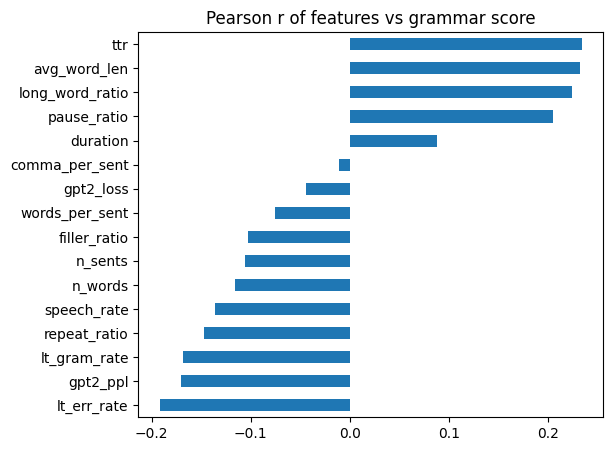

In [6]:
# Interpretability: correlation of each handcrafted feature with the label
corr = hc_tr.assign(y=train[LABEL_COL].values).corr()["y"].drop("y").sort_values()
corr.plot.barh(figsize=(6, 5), title="Pearson r of features vs grammar score"); plt.show()

## 4. Modelling
Three feature views, each with a suitable regressor, then averaged:
1. **Ridge** on handcrafted + SBERT + wav2vec2 (standardised)
2. **SVR (RBF)** on handcrafted + PCA(SBERT) + PCA(wav2vec2)
3. **Gradient Boosting** on handcrafted + PCA components

Validation: 5-fold CV, metric = RMSE (also Pearson r). Predictions are clipped to [0, 5].

In [7]:
y = train[LABEL_COL].values.astype(float)
X_all_tr = np.hstack([hc_tr.values, sb_tr, wv_tr])
X_all_te = np.hstack([hc_te.values, sb_te, wv_te])



def make_views(tr_idx, va_idx, Xte_extra=None):
    """Fit PCA only on the training fold to avoid leakage; return compact feature views."""
    sc = StandardScaler().fit(hc_tr.values[tr_idx])
    p1 = PCA(20, random_state=SEED).fit(sb_tr[tr_idx]); p2 = PCA(30, random_state=SEED).fit(wv_tr[tr_idx])
    def f(hc, sb, wv): return np.hstack([sc.transform(hc), p1.transform(sb), p2.transform(wv)])
    return f

def models():
    return {
        "ridge": make_pipeline(StandardScaler(), Ridge(alpha=300)),
        "svr":   make_pipeline(StandardScaler(), SVR(C=3, epsilon=0.2, gamma="scale")),
        "gbr":   GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.8, random_state=SEED),
    }
def view_for(name, Xfull, Xcompact):
    return Xfull if name == "ridge" else Xcompact

rmse = lambda a, b: np.sqrt(mean_squared_error(a, b))
kf = KFold(5, shuffle=True, random_state=SEED)
oof = {k: np.zeros(len(y)) for k in models()}

for fold, (tr_i, va_i) in enumerate(kf.split(X_all_tr)):
    f = make_views(tr_i, va_i)
    Xc = f(hc_tr.values, sb_tr, wv_tr)
    for name, m in models().items():
        Xv = view_for(name, X_all_tr, Xc)
        m.fit(Xv[tr_i], y[tr_i]); oof[name][va_i] = m.predict(Xv[va_i])
    print(f"fold {fold} done")

oof_ens = np.clip(np.mean(list(oof.values()), axis=0), 0, 5)
for k, v in oof.items(): print(f"{k:6s} CV RMSE = {rmse(y, np.clip(v,0,5)):.4f}")
print(f"ENSEMBLE CV RMSE = {rmse(y, oof_ens):.4f} | Pearson r = {pearsonr(y, oof_ens)[0]:.4f}")
print(f"Baseline (predict mean) RMSE = {rmse(y, np.full_like(y, y.mean())):.4f}")

fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done
ridge  CV RMSE = 0.6246
svr    CV RMSE = 0.7166
gbr    CV RMSE = 0.6696
ENSEMBLE CV RMSE = 0.6217 | Pearson r = 0.8704
Baseline (predict mean) RMSE = 1.2382


## 5. Final fit on full training data - **Training RMSE** (required) and diagnostics

TRAINING RMSE      : 0.2705
CV (5-fold) RMSE   : 0.6217
Training Pearson r : 0.9803


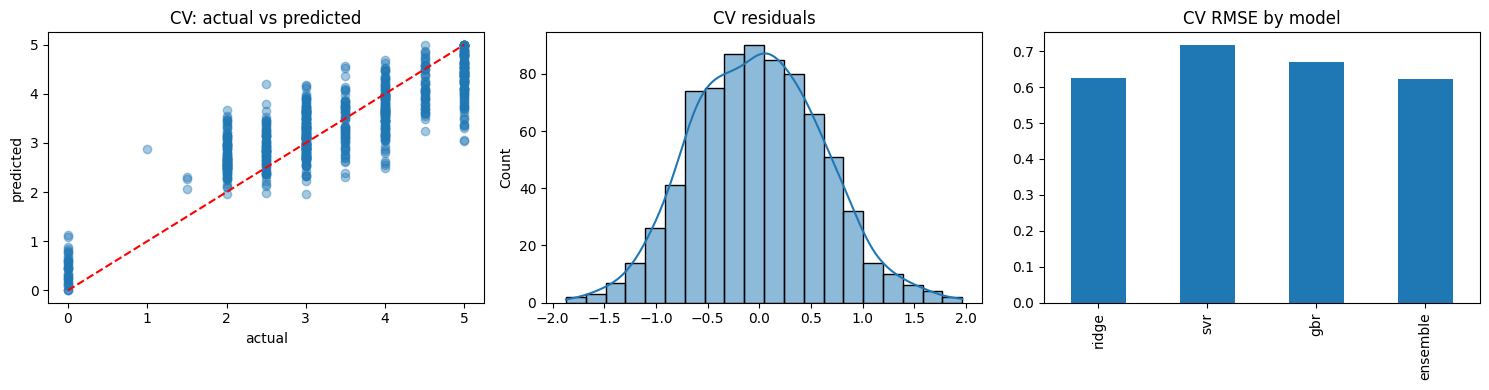

In [8]:
all_idx = np.arange(len(y))
f_full = make_views(all_idx, None)
Xc_tr, Xc_te = f_full(hc_tr.values, sb_tr, wv_tr), f_full(hc_te.values, sb_te, wv_te)

tr_preds, te_preds = [], []
for name, m in models().items():
    Xtr = view_for(name, X_all_tr, Xc_tr); Xte = view_for(name, X_all_te, Xc_te)
    m.fit(Xtr, y); tr_preds.append(m.predict(Xtr)); te_preds.append(m.predict(Xte))

train_pred = np.clip(np.mean(tr_preds, axis=0), 0, 5)
test_pred  = np.clip(np.mean(te_preds, axis=0), 0, 5)

print("=" * 45)
print(f"TRAINING RMSE      : {rmse(y, train_pred):.4f}")
print(f"CV (5-fold) RMSE   : {rmse(y, oof_ens):.4f}")
print(f"Training Pearson r : {pearsonr(y, train_pred)[0]:.4f}")
print("=" * 45)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(y, oof_ens, alpha=.4); ax[0].plot([0,5],[0,5],"r--"); ax[0].set(title="CV: actual vs predicted", xlabel="actual", ylabel="predicted")
sns.histplot(y - oof_ens, kde=True, ax=ax[1]); ax[1].set_title("CV residuals")
pd.Series({k: rmse(y, np.clip(v,0,5)) for k, v in oof.items()} | {"ensemble": rmse(y, oof_ens)}).plot.bar(ax=ax[2], title="CV RMSE by model")
plt.tight_layout(); plt.show()

## 6. Test predictions & submission

In [9]:
fcol, lcol = sub.columns[0], sub.columns[1]
out = pd.DataFrame({fcol: test[FILE_COL].values, lcol: test_pred})
out.to_csv("submission.csv", index=False)
print(out.shape); display(out.head()); print(out[lcol].describe())

(216, 2)


,filename,label
0,audio_128.wav,3.086520
1,audio_156.wav,3.927450
2,audio_19.wav,4.290444
3,audio_108.wav,2.637264
4,audio_206.wav,2.524074


count    216.000000
mean       3.197532
std        0.667870
min        1.840182
25%        2.712492
50%        3.112382
75%        3.560039
max        5.000000
Name: label, dtype: float64


## 7. Report

**Problem.** Predict a continuous MOS grammar score (0-5) from 45-60 s spoken clips (769 train / 216 test).

**Pipeline.**
1. *Preprocessing:* audio resampled to 16 kHz mono and transcribed with Whisper-small; transcripts are cached.
2. *Features:* (a) linguistic/fluency statistics (length, type-token ratio, fillers, repetitions, speech rate, pause ratio), (b) GPT-2 perplexity, (c) LanguageTool grammar-error rate, (d) MiniLM sentence embeddings, (e) wav2vec2 mean/std-pooled acoustic embeddings.
3. *Models:* Ridge, RBF-SVR and Gradient Boosting. PCA is fitted inside each CV fold to avoid leakage. Predictions are averaged and clipped to [0, 5].
4. *Evaluation:* 5-fold cross-validated RMSE and Pearson r, plus the compulsory training RMSE.

**Results.**

| Metric | Value |
|---|---|
| Training RMSE | 0.2705 |
| 5-fold CV RMSE (ensemble) | 0.6217 |
| CV Pearson r | 0.8704 |
| Baseline (predict the mean) RMSE | 1.2382 |

CV RMSE by model: Ridge 0.6246, SVR 0.7166, Gradient Boosting 0.6696, ensemble 0.6217. Training RMSE is optimistic because the models have seen those rows; CV RMSE is the realistic estimate of test performance. CV residuals are roughly normal and centred at zero, with predictions shrunk toward the mean at the extremes (scores 0 and 5).

**Interpretability.** Lexical richness (type-token ratio, average and long word length) correlates positively with the score. LanguageTool error rates, GPT-2 perplexity, repetition and speech rate correlate negatively. Individual correlations are modest (|r| below 0.25), so predictive power comes mainly from combining many features, including the embeddings.

**Data notes.** train.csv and test.csv reuse the same file names (audio_0, audio_1, ...) in separate train/ and test/ folders, so audio is matched per split folder to prevent leakage. sample_submission.csv lists only 204 names that mostly do not match test.csv, so the submission follows the 216 files in test.csv. One label-0 training clip made Whisper loop (~1,100 words); the repetition and perplexity features capture such cases.

**Limitations / next steps.** Whisper partly normalises grammar errors. Possible improvements: larger Whisper models, fine-tuning a transformer (e.g., DeBERTa) on transcripts, fine-tuning wav2vec2 end-to-end, and tuning the ensemble weights.